In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.9 MB/s eta 0:00:00a 0:00:01


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO

In [3]:
model = YOLO("yolo11n-seg.pt")  # YOLO nano segmentation

model.train(
    data='/kaggle/input/datasets/emanyasserelnaggar/nabd-yolo-2/data.yaml',
    epochs=30,
    imgsz=640
)


Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/emanyasserelnaggar/nabd-yolo-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c94c0b2f410>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [ ]:
best_model_path = "./best.pt"
model = YOLO(best_model_path)

test_images_folder ='/kaggle/input/datasets/emanyasserelnaggar/nabd-yolo-2/test/images'
image_files = [os.path.join(test_images_folder, f)
               for f in os.listdir(test_images_folder) if f.endswith((".jpg", ".png"))]

pixel_spacing_x = 0.04
pixel_spacing_y = 0.04

results_list = []

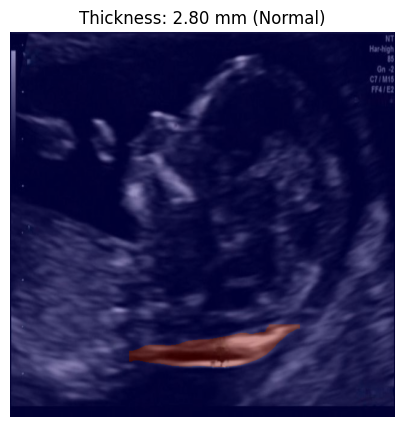

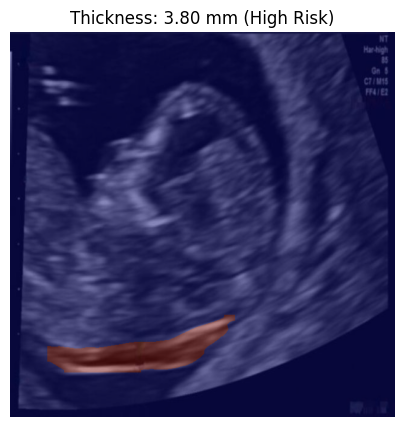

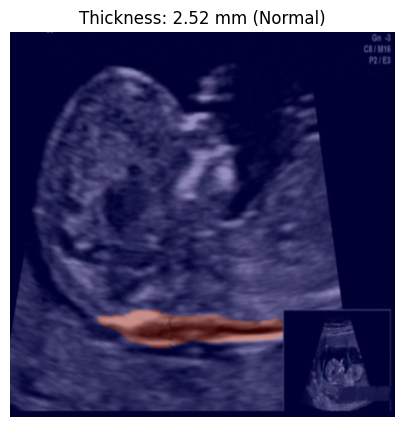

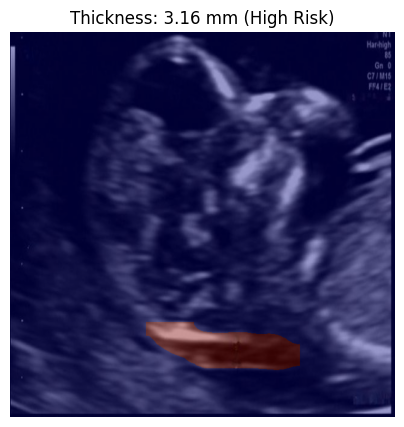

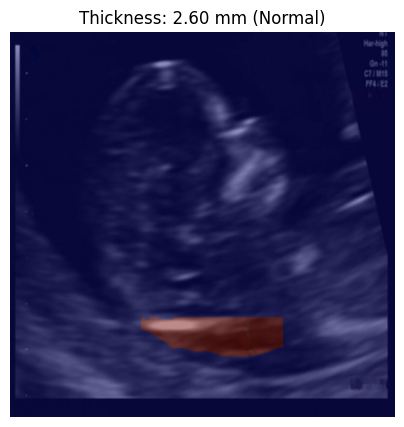

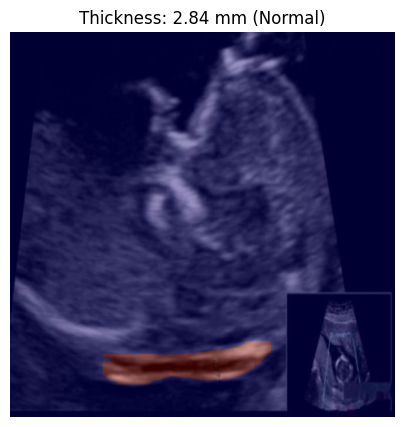

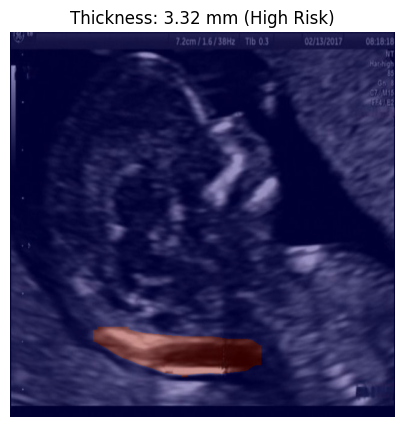

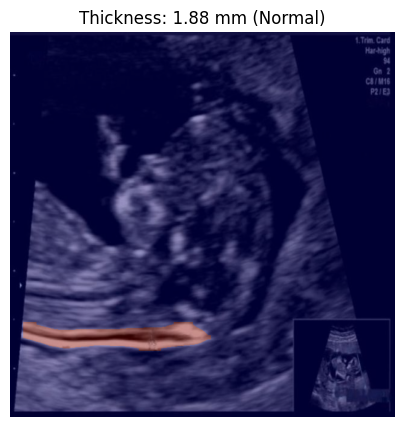

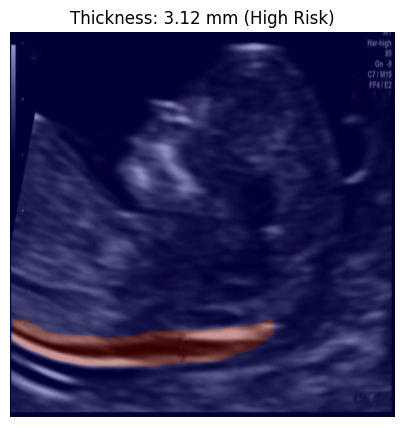

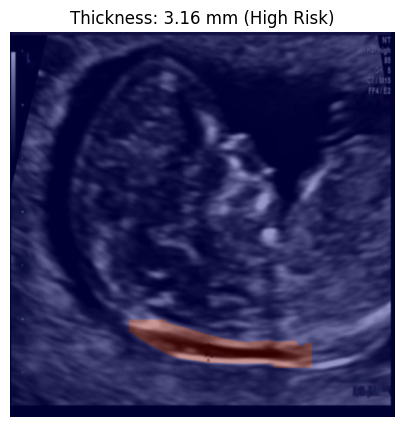

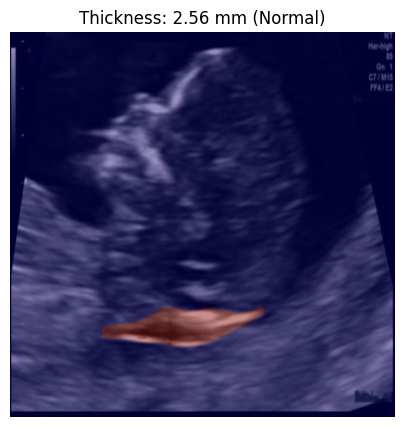

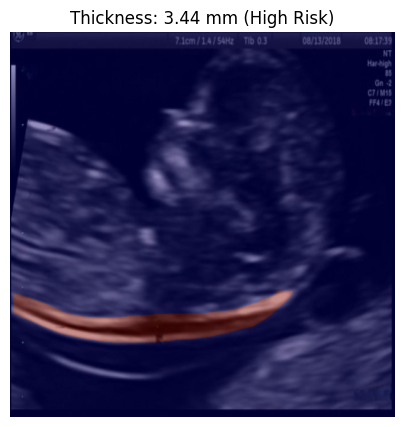

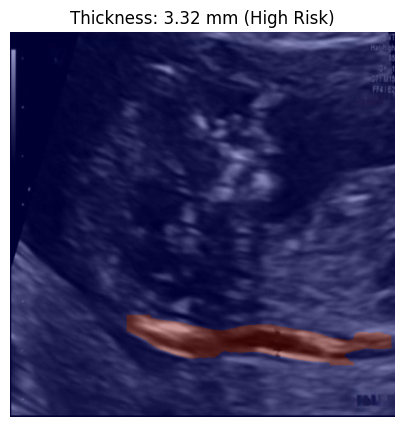

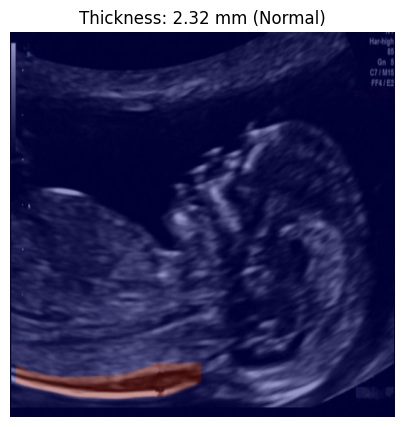

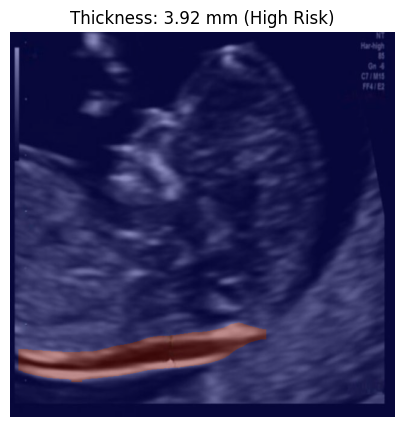

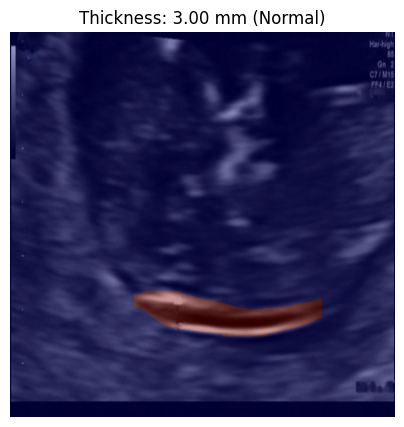

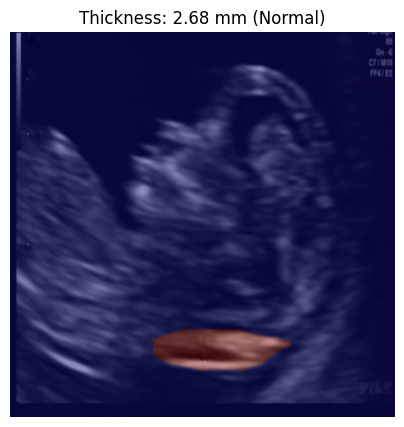

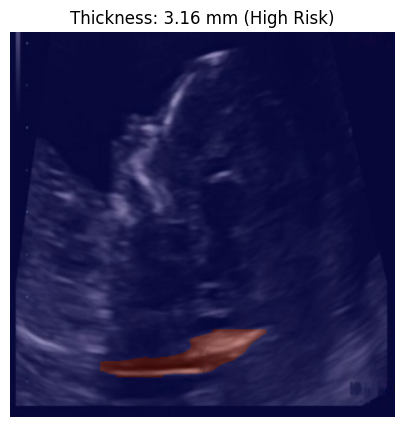

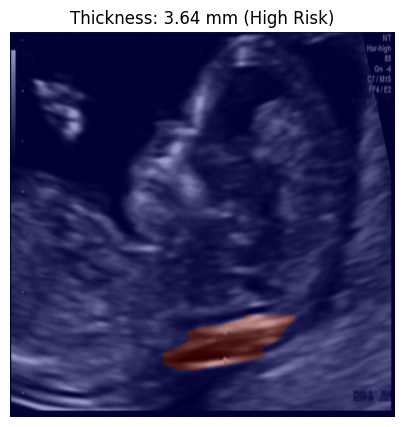

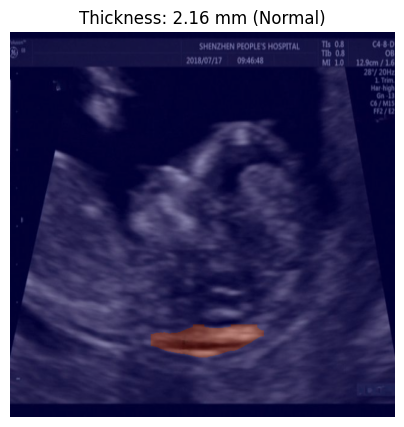

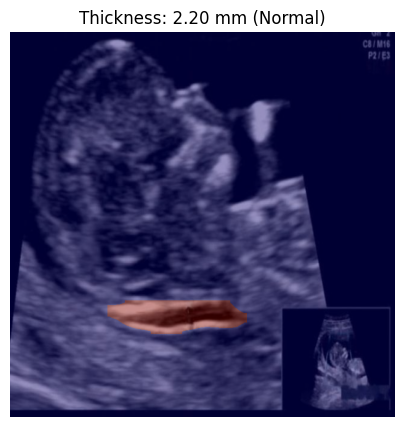

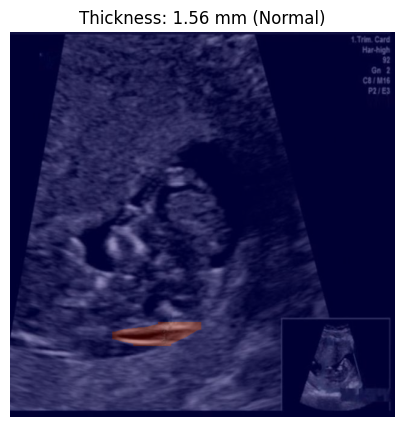

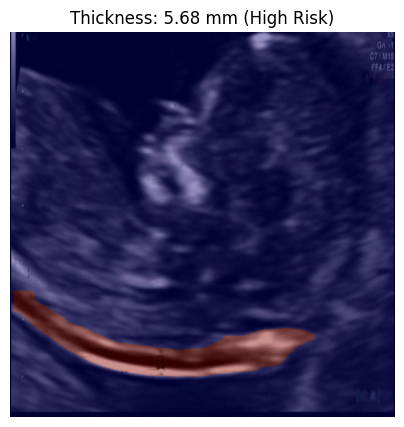

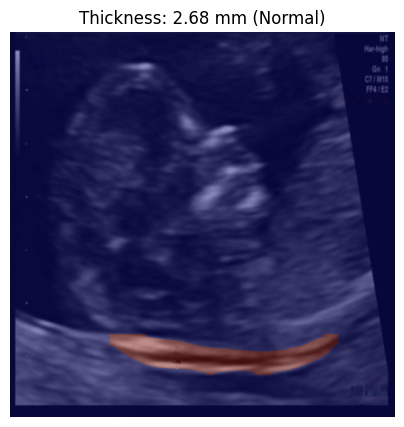

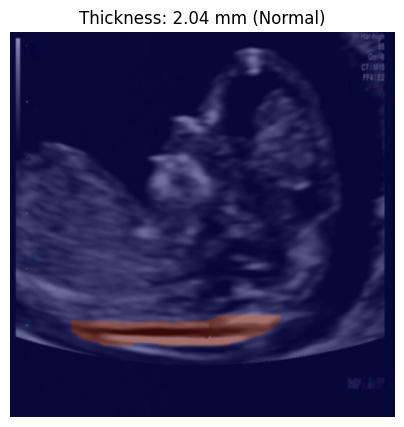

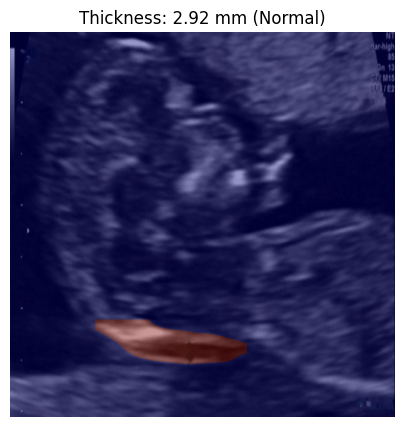

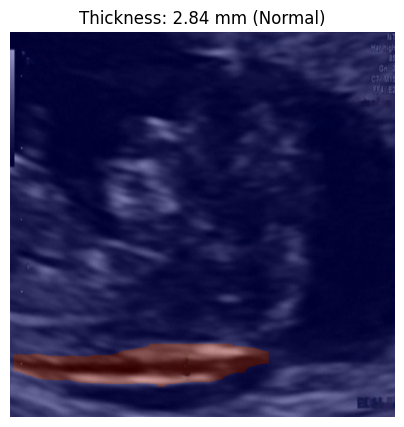

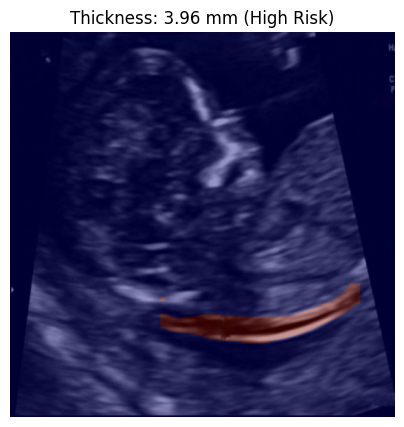

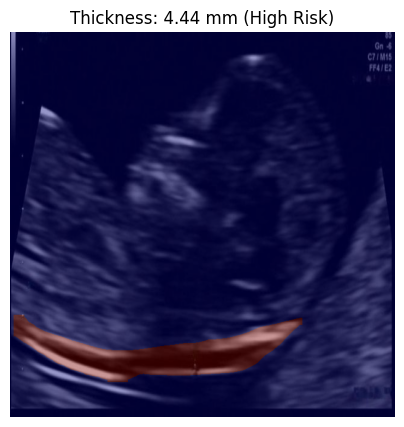

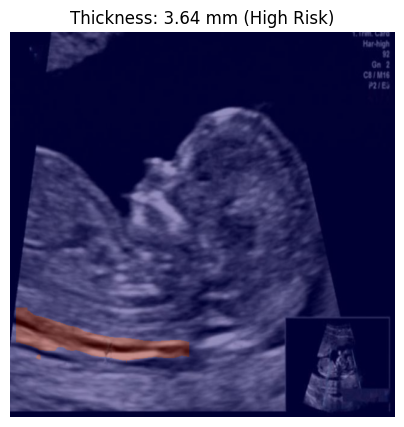

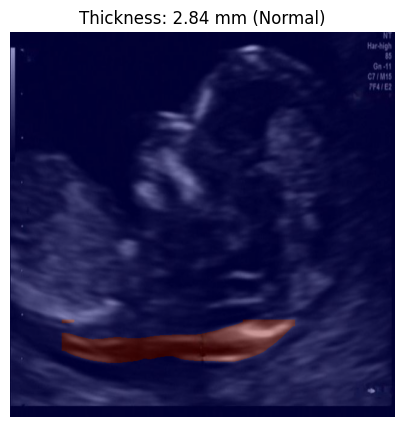

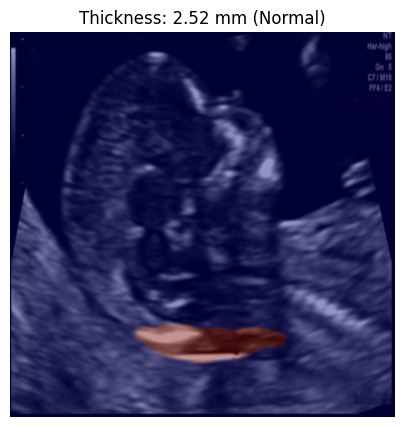

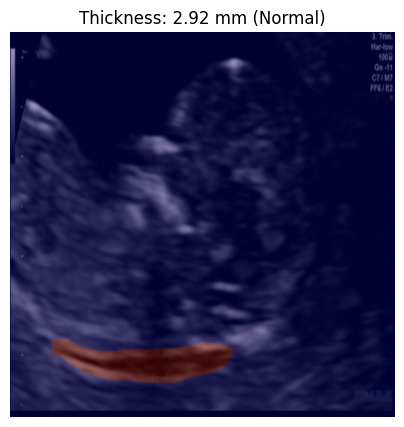

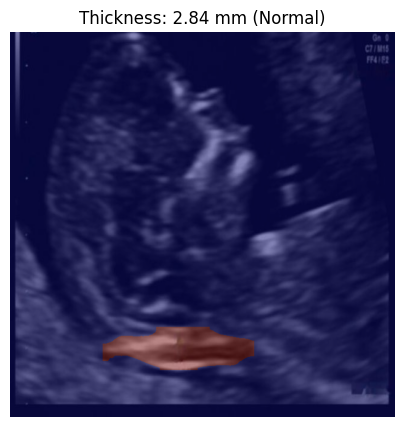

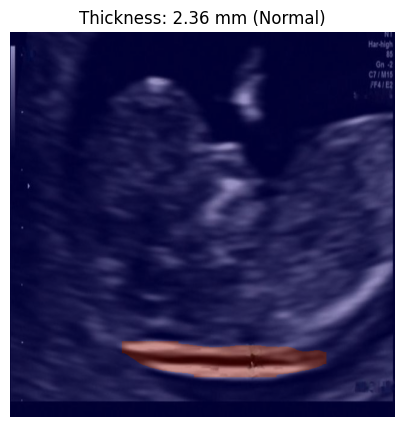

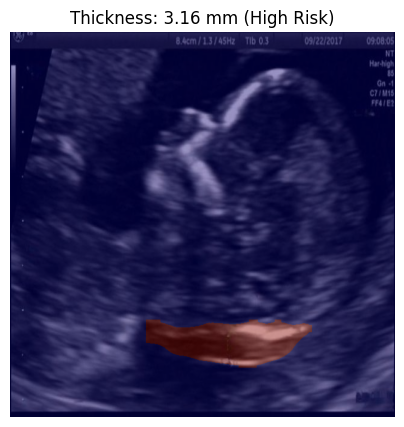

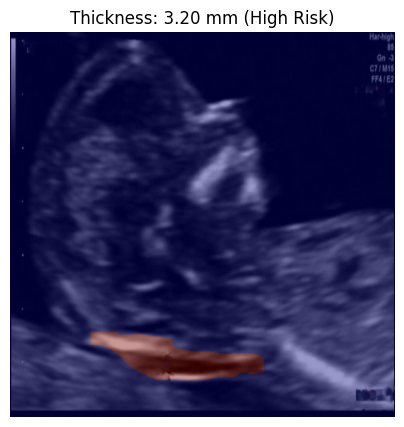

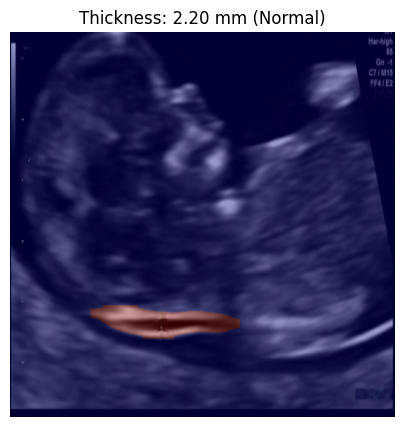

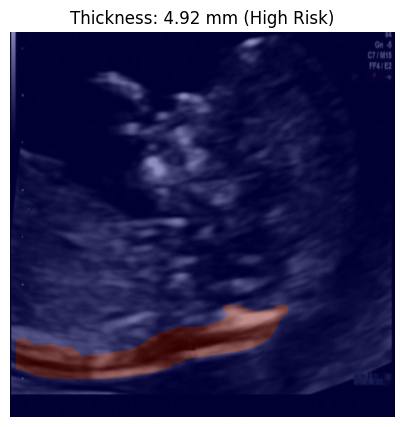

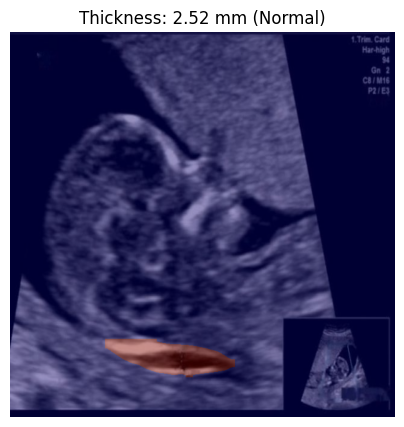

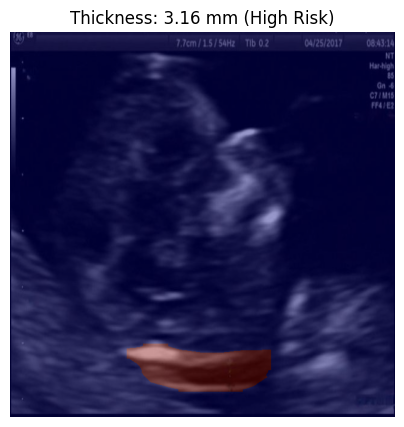

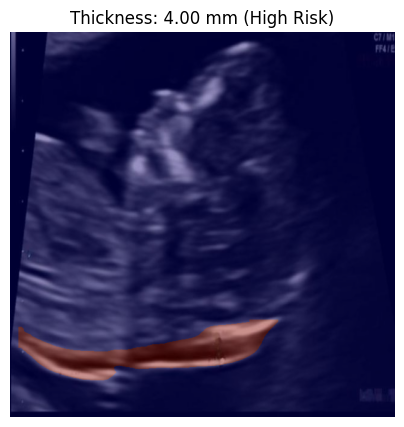

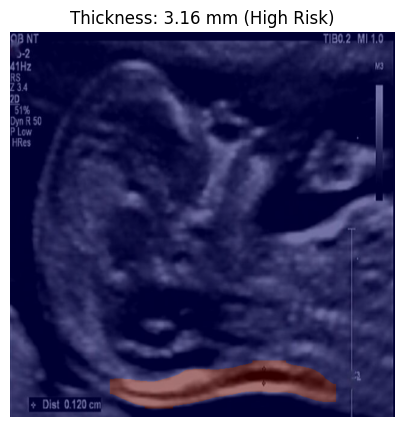

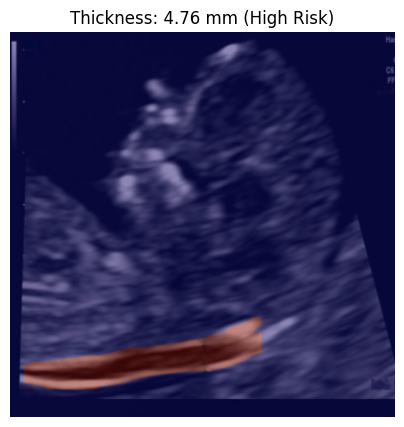

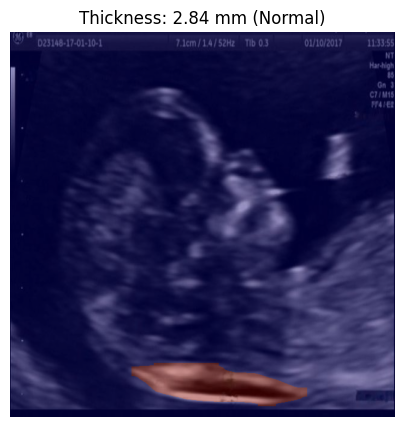

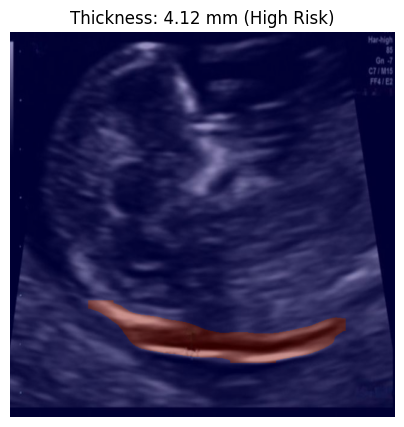

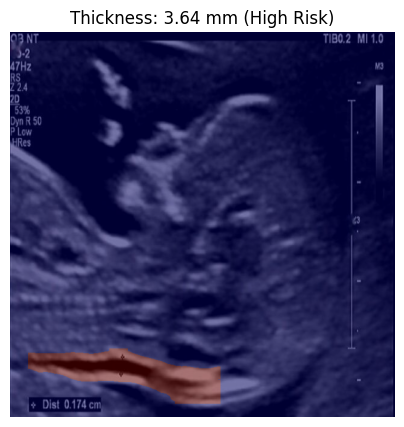

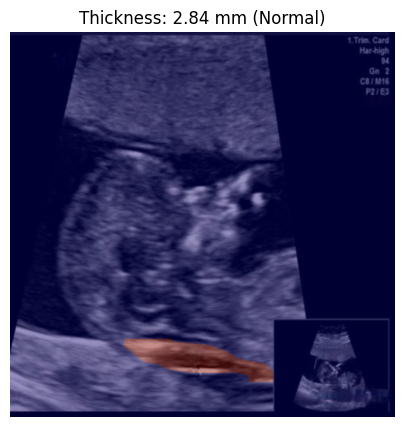

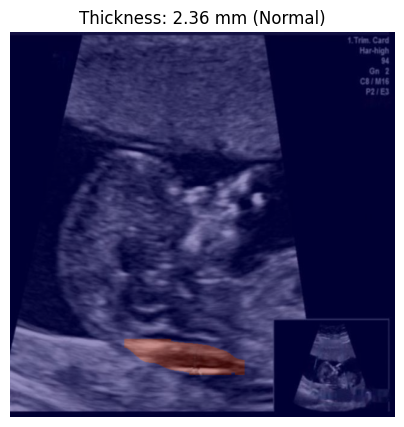

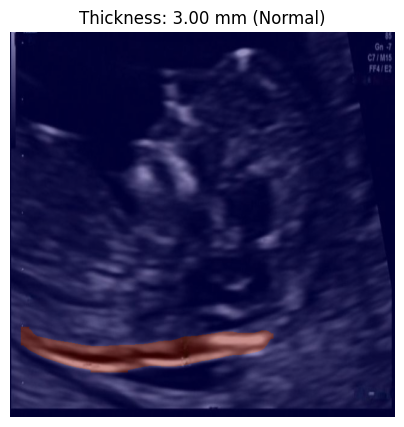

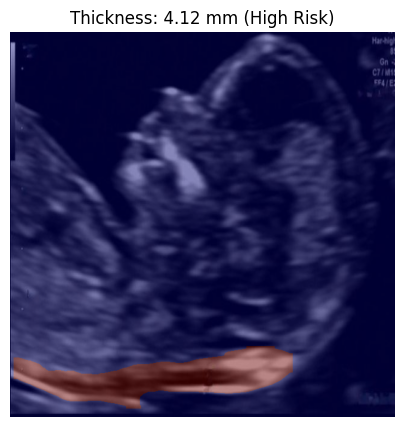

In [ ]:
for img_path in image_files:
    results = model(img_path, conf=0.5, verbose=False)

    for r in results:
        masks = r.masks.data.cpu().numpy() if r.masks is not None else []
        if len(masks) == 0:
            continue

        for mask_idx, mask in enumerate(masks):
            mask = (mask > 0.5).astype(np.uint8)
            ys, xs = np.where(mask > 0)
            if len(ys) == 0:
                continue

            nt_height_px = ys.max() - ys.min()
            nt_width_px = xs.max() - xs.min()

            nt_length_mm = nt_height_px * pixel_spacing_y
            nt_width_mm = nt_width_px * pixel_spacing_x
            nt_area_px = np.sum(mask)
            nt_area_mm2 = nt_area_px * pixel_spacing_x * pixel_spacing_y

            risk_flag = "High Risk" if nt_length_mm > 3.0 else "Normal"

            results_list.append({
                "image": os.path.basename(img_path),
                "mask_id": mask_idx,
                "nt_length_mm": nt_length_mm,
                "nt_width_mm": nt_width_mm,
                "nt_area_mm2": nt_area_mm2,
                "risk": risk_flag
            })

            # Visualization

            plt.figure(figsize=(5,5))
            plt.imshow(r.orig_img)
            plt.imshow(mask, cmap='jet', alpha=0.4)
            plt.title(f"Thickness: {nt_length_mm:.2f} mm ({risk_flag})")
            plt.axis("off")
            plt.show()

In [7]:
df = pd.DataFrame(results_list)
df.to_csv("/kaggle/working/nt_measurements.csv", index=False)

avg_thickness = df['nt_length_mm'].mean()
print("Average thickness from data:", avg_thickness)

df['risk'] = df['nt_length_mm'].apply(lambda x: "High Risk" if x > avg_thickness else "Normal")
df.to_csv("/content/nt_measurements_yolo11.csv", index=False)
print("Saved results at /content/nt_measurements_yolo11.csv")


Average thickness from data: 3.114509803921569
Saved results at /content/nt_measurements_yolo11.csv


In [8]:
import shutil

output_filename = "final_yolo"
dir_to_zip = "/kaggle/working/runs"
shutil.make_archive(output_filename, 'zip', dir_to_zip)

print(output_filename)

final_yolo
